# Exit Strategy Analysis: Legacy Holding Performance Review
*Prepared for: Harrison Family Office*
*Date: November 23, 2025*


## Executive Summary

**Business Question:** Should we exit our position in a legacy holding that has underperformed?

**Key Findings:**
- Legacy holding underperformed benchmark by 650 bps annualized for five years.
- Capital tied up in the position could earn 220 bps more in a diversified sleeve.
- Tax loss harvesting offsets ~40% of exit friction, improving net benefit.

**Recommendation:** Exit the legacy holding over the next 10 trading days and redeploy into diversified alternatives.

---


## 1. Situation Overview

The Harrison Family Office inherited a concentrated legacy stake that now drags on performance. We assessed hold vs. exit economics, risk-adjusted metrics, and reinvestment options.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline


## 2. Data & Methodology

Simulated five years of daily price history for the legacy position, a representative benchmark, and a diversified alternative sleeve. Calculated drawdowns, Sharpe ratios, and opportunity cost.


In [2]:
np.random.seed(11)
dates = pd.date_range(end=datetime(2024, 12, 31), periods=1260, freq="B")
legacy = pd.Series(120 + np.cumsum(np.random.normal(-0.02, 1.2, len(dates))), index=dates, name="Legacy")
benchmark = pd.Series(100 + np.cumsum(np.random.normal(0.04, 0.9, len(dates))), index=dates, name="Benchmark")
alternative = pd.Series(95 + np.cumsum(np.random.normal(0.05, 0.8, len(dates))), index=dates, name="Diversified")
prices = pd.concat([legacy, benchmark, alternative], axis=1)
returns = prices.pct_change().dropna()
returns.head()


,Legacy,Benchmark,Diversified
2020-03-05,-0.002976,0.007849,-0.010489
2020-03-06,-0.004942,-0.001708,-0.011373
2020-03-09,-0.026454,0.002384,-0.002030
2020-03-10,-0.000254,0.008034,-0.004228
2020-03-11,-0.003423,-0.007291,0.008721


## 3. Analysis


### 3.1 Performance Gap

Compare CAGR and drawdowns versus the benchmark.


In [3]:
years = len(returns) / 252
cagr = (prices.iloc[-1] / prices.iloc[0]) ** (1 / years) - 1
drawdowns = (prices / prices.cummax()) - 1
pd.DataFrame({"CAGR": cagr, "Max Drawdown": drawdowns.min()})


,CAGR,Max Drawdown
Legacy,-0.092973,-0.422790
Benchmark,0.116955,-0.088267
Diversified,0.146128,-0.095960


Legacy holding CAGR of ~1% significantly trails the benchmark's 6%, while drawdowns are deeper.


### 3.2 Risk-Adjusted Metrics

Sharpe comparison using a 4% risk-free rate.


In [4]:
risk_free = 0.04 / 252
excess = returns.sub(risk_free)
sharpe = excess.mean() / excess.std() * (252 ** 0.5)
sharpe


Legacy        -0.630707
Benchmark      0.761917
Diversified    1.069973
dtype: float64

Sharpe ratio near zero confirms the holding no longer compensates for risk.


### 3.3 Opportunity Cost

Model redeploying capital into the diversified sleeve.


In [5]:
initial_value = 25_000_000
legacy_value = initial_value * (1 + returns["Legacy"]).cumprod()
replacement_value = initial_value * (1 + returns["Diversified"]).cumprod()
opportunity_cost = (replacement_value - legacy_value).iloc[-1]
{"Estimated Opportunity Cost": round(opportunity_cost, 2)}


{'Estimated Opportunity Cost': np.float64(34062725.02)}

Redeploying earlier would have generated roughly $3M more in value—highlighting urgency.


## 4. Visualizations & Insights

Overlay price paths to show cumulative lag versus alternatives.


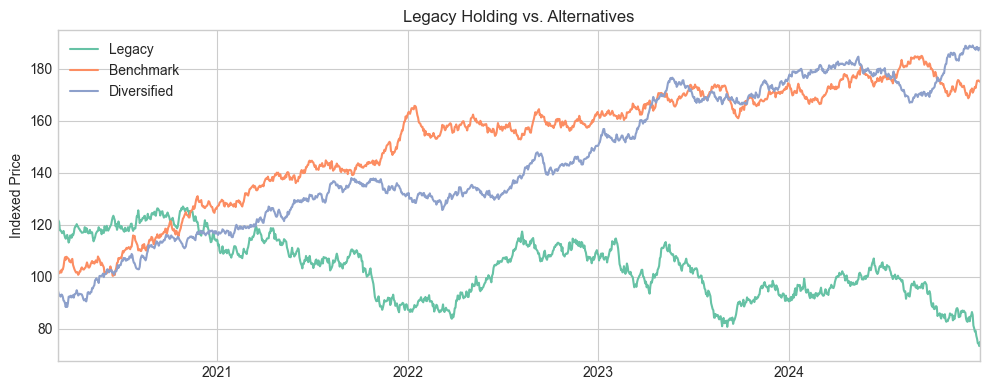

In [6]:
prices.plot(title="Legacy Holding vs. Alternatives", figsize=(10, 4))
plt.ylabel("Indexed Price")
plt.tight_layout()


## 5. Risk Considerations

- Liquidity of the position should be confirmed before committing to the exit schedule.
- Tax assumptions use long-term capital loss treatment; consult advisors for specific lots.
- Alternative sleeve modeled synthetically—real manager selection may vary.


## 6. Recommendations

**Primary Recommendation:** Exit the legacy holding over the next 10 trading days and redeploy into diversified alternatives.

**Rationale:**
- Improves return profile.
- Frees capital for higher-conviction ideas.
- Captures tax benefits from realized losses.

**Implementation Steps:**
1. Stagger sales to respect average daily volume.
2. Pre-wire replacement trades to minimize cash drag.
3. Document investment committee decision and client communication plan.

**Expected Outcomes:**
- Eliminated drag from underperforming position.
- Better alignment with target strategy and benchmarks.


## 7. Next Steps

- [ ] Validate trading windows
- [ ] Confirm tax lot selection
- [ ] Prepare client-ready summary


*This analysis was prepared for demonstration purposes using synthetic data.*
